In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from dateutil import parser

# For text analysis
import nltk
from nltk.corpus import stopwords
from collections import Counter

# Download nltk resources (run once)
nltk.download('stopwords')

# Configuration for clear plots
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Her\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


In [2]:
# Load dataset (Update the path to where your csv file is located)
df = pd.read_csv('../src/raw_analyst_ratings.csv') 
# Note: Assuming the file is in a 'data' folder outside 'notebooks'

# Display first few rows
display(df.head())

# Check data types and missing values
print(df.info())

,Unnamed: 0,headline,url,publisher,date,stock
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 10:30:54-04:00,A
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 10:45:20-04:00,A
2,2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 04:30:07-04:00,A
3,3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 12:45:06-04:00,A
4,4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 11:38:59-04:00,A


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1407328 entries, 0 to 1407327
Data columns (total 6 columns):
 #   Column      Non-Null Count    Dtype 
---  ------      --------------    ----- 
 0   Unnamed: 0  1407328 non-null  int64 
 1   headline    1407328 non-null  object
 2   url         1407328 non-null  object
 3   publisher   1407328 non-null  object
 4   date        1407328 non-null  object
 5   stock       1407328 non-null  object
dtypes: int64(1), object(5)
memory usage: 64.4+ MB
None


In [3]:
# Convert date column to datetime
df['date'] = pd.to_datetime(df['date'], errors='coerce', utc=True)

count    1.407328e+06
mean     7.312051e+01
std      4.073531e+01
min      3.000000e+00
25%      4.700000e+01
50%      6.400000e+01
75%      8.700000e+01
max      5.120000e+02
Name: headline_length, dtype: float64


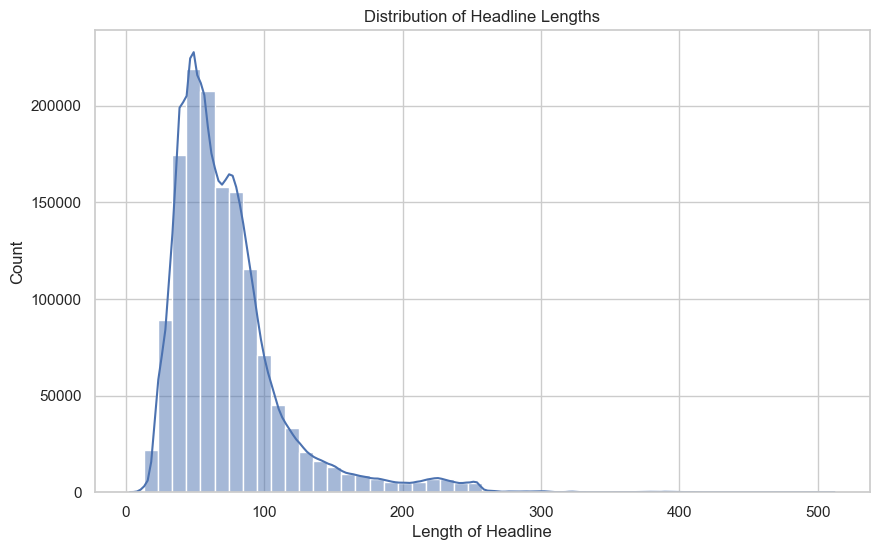

In [4]:
# Calculate headline length
df['headline_length'] = df['headline'].apply(len)

# basic stats
print(df['headline_length'].describe())

# Visualize the distribution
plt.figure(figsize=(10, 6))
sns.histplot(df['headline_length'], bins=50, kde=True)
plt.title('Distribution of Headline Lengths')
plt.xlabel('Length of Headline')
plt.show()

publisher
Paul Quintaro        228373
Lisa Levin           186979
Benzinga Newsdesk    150484
Charles Gross         96732
Monica Gerson         82380
Eddie Staley          57254
Hal Lindon            49047
ETF Professor         28489
Juan Lopez            28438
Benzinga Staff        28114
Name: count, dtype: int64


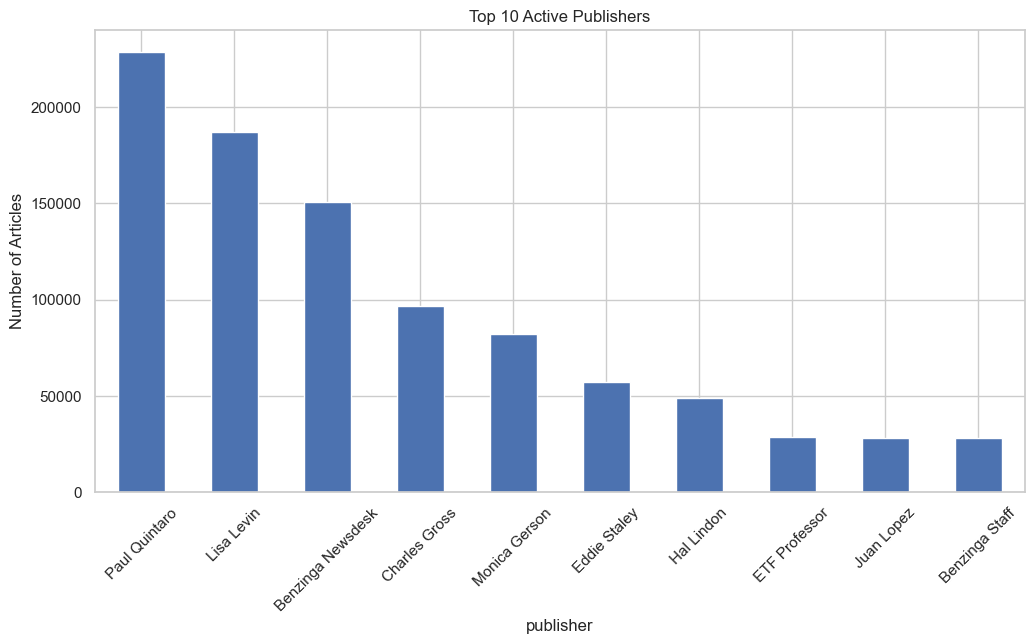

In [5]:
# Count articles per publisher
publisher_counts = df['publisher'].value_counts()

# Print top 10 publishers
print(publisher_counts.head(10))

# Visualize Top 10
plt.figure(figsize=(12, 6))
publisher_counts.head(10).plot(kind='bar')
plt.title('Top 10 Active Publishers')
plt.ylabel('Number of Articles')
plt.xticks(rotation=45)
plt.show()

In [7]:
# If publisher names look like emails, extract the domain
df['publisher_domain'] = df['publisher'].apply(lambda x: x.split('@')[-1] if '@' in x else x)
print(df['publisher_domain'].value_counts().head())

publisher_domain
Paul Quintaro        228373
Lisa Levin           186979
Benzinga Newsdesk    150484
Charles Gross         96732
Monica Gerson         82380
Name: count, dtype: int64


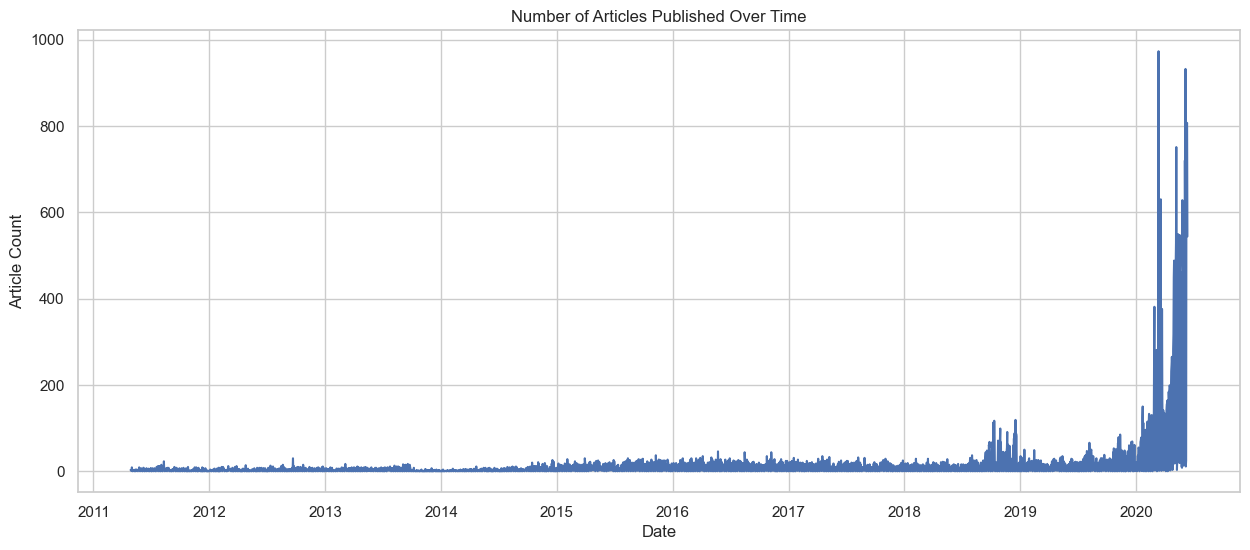

C:\Users\Her\AppData\Local\Temp\ipykernel_51908\825039590.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='hour', data=df, palette='viridis')


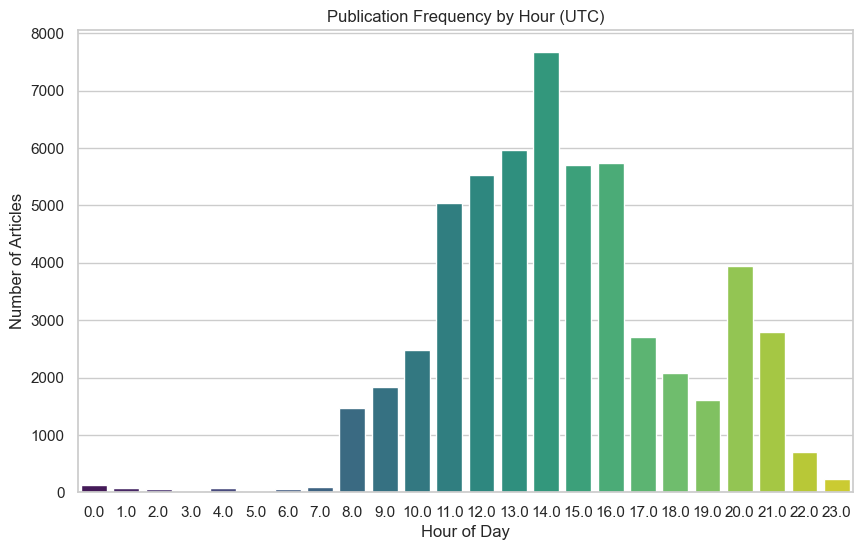

In [8]:
# 1. Articles per Day
daily_counts = df.resample('D', on='date').count()

plt.figure(figsize=(15, 6))
plt.plot(daily_counts.index, daily_counts['headline'])
plt.title('Number of Articles Published Over Time')
plt.xlabel('Date')
plt.ylabel('Article Count')
plt.show()

# 2. Articles by Hour (Market hours analysis)
df['hour'] = df['date'].dt.hour

plt.figure(figsize=(10, 6))
sns.countplot(x='hour', data=df, palette='viridis')
plt.title('Publication Frequency by Hour (UTC)')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Articles')
plt.show()

In [11]:
import nltk

# Download the tokenizer models
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Her\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Her\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.


True

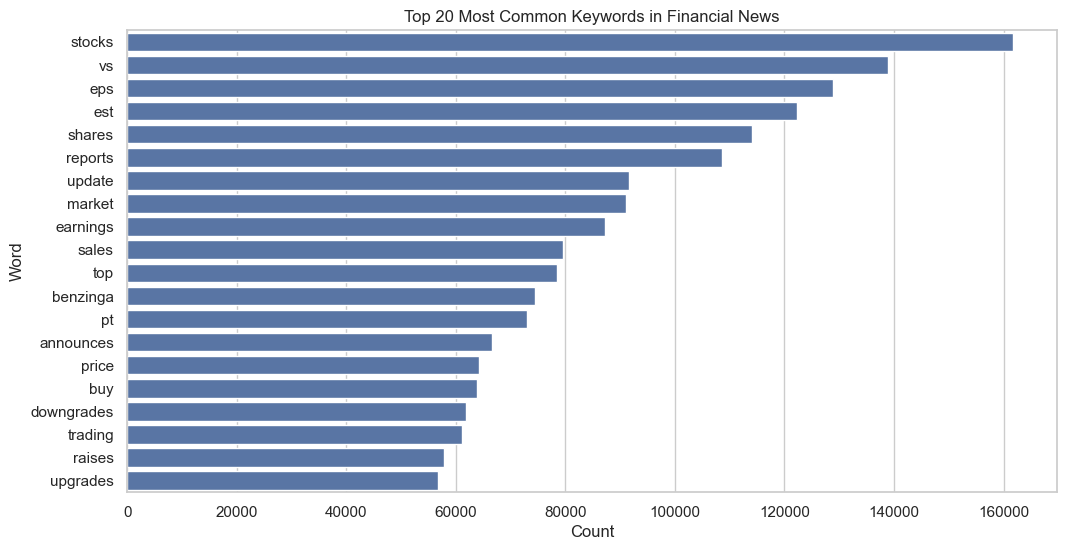

In [12]:
# Combine all headlines into one string
all_text = ' '.join(df['headline'].astype(str))

# Tokenize and remove stop words
stop_words = set(stopwords.words('english'))
words = nltk.word_tokenize(all_text.lower())
filtered_words = [word for word in words if word.isalnum() and word not in stop_words]

# Count most common words
word_counts = Counter(filtered_words)
common_words = word_counts.most_common(20)

# Plot common words
words_df = pd.DataFrame(common_words, columns=['Word', 'Count'])
plt.figure(figsize=(12, 6))
sns.barplot(x='Count', y='Word', data=words_df)
plt.title('Top 20 Most Common Keywords in Financial News')
plt.show()

In [13]:
# Check for specific financial phrases
topics = ['FDA approval', 'price target', 'earnings', 'dividend']

for topic in topics:
    count = df['headline'].str.contains(topic, case=False).sum()
    print(f"Articles mentioning '{topic}': {count}")

Articles mentioning 'FDA approval': 1546
Articles mentioning 'price target': 47634
Articles mentioning 'earnings': 86626
Articles mentioning 'dividend': 21572
